# Time Series Forecasting with Neural Networks

## What We'll Learn

Time series forecasting is the task of predicting future values based on historical observations. Unlike static prediction tasks, time series data has a **temporal structure** — the order of observations matters.

**In this notebook, we'll:**
- Understand key time series concepts: stationarity, trends, seasonality, and temporal windows
- Learn how to preprocess time series data for neural networks
- Build three forecasting models with increasing sophistication:
  - **MLP Baseline**: Simple feedforward network
  - **LSTM**: Captures long-term dependencies through memory cells
  - **Transformer**: Uses attention to model temporal relationships
- Evaluate models with appropriate metrics (MAE, RMSE, MAPE)
- Visualize predictions and understand model behavior

**Why This Matters:**

Time series forecasting powers countless real-world applications:
- **Finance**: Stock price prediction, risk assessment
- **Energy**: Demand forecasting, grid optimization
- **Weather**: Temperature, rainfall predictions
- **Healthcare**: Patient monitoring, disease outbreak prediction
- **E-commerce**: Demand forecasting, inventory management

Understanding how to model temporal dependencies is essential for any ML practitioner.

## 1. Setup and Data Loading

### Import Dependencies

We'll use PyTorch for model building, pandas for data handling, and our shared utilities for device management and reproducibility.

In [ ]:



%load_ext autoreload
%autoreload 2

### Set Random Seed for Reproducibility

Neural networks are stochastic by nature (random initialization, data shuffling). Setting a seed ensures our results are reproducible.

In [ ]:
from aiml_notebooks import get_device, set_seed, count_parameters, TrainingHistory

In [2]:
set_seed(42)

### Configure Device

We'll use GPU acceleration if available. Time series models can be computationally intensive, especially with long sequences.

In [3]:
device = get_device()

Using MPS (Metal Performance Shaders) for GPU acceleration


### Load Real-World Dataset: Air Quality (Beijing PM2.5)

We'll use the Beijing PM2.5 dataset, which contains hourly air pollution measurements. This is a classic time series forecasting problem.

**Dataset features:**
- **PM2.5**: Particulate matter concentration (our target)
- **Temperature, Pressure, Humidity**: Weather conditions
- **Wind Speed/Direction**: Environmental factors
- Hourly measurements from 2010-2014

We'll create synthetic data with similar characteristics for this notebook (trend + seasonality + noise).

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [4]:
# Generate synthetic time series data (trend + daily seasonality + noise)
np.random.seed(42)

# 2 years of hourly data
n_hours = 24 * 365 * 2
time = np.arange(n_hours)

# Components:
# 1. Trend: slowly increasing pollution over time
trend = 0.001 * time

# 2. Daily seasonality: pollution peaks during rush hours (8am, 6pm)
daily_pattern = 20 * np.sin(2 * np.pi * time / 24) + 15 * np.sin(4 * np.pi * time / 24)

# 3. Weekly seasonality: less pollution on weekends
weekly_pattern = -10 * np.sin(2 * np.pi * time / (24 * 7))

# 4. Random noise
noise = np.random.normal(0, 5, n_hours)

# Combine components
pm25 = 50 + trend + daily_pattern + weekly_pattern + noise
pm25 = np.maximum(pm25, 0)  # PM2.5 can't be negative

# Create DataFrame
dates = pd.date_range('2020-01-01', periods=n_hours, freq='h')
df = pd.DataFrame({
    'datetime': dates,
    'pm25': pm25
})

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nStatistics:")
print(df['pm25'].describe())

Dataset shape: (17520, 2)

First few rows:
             datetime       pm25
0 2020-01-01 00:00:00  52.483571
1 2020-01-01 01:00:00  61.612147
2 2020-01-01 02:00:00  75.483523
3 2020-01-01 03:00:00  85.640640
4 2020-01-01 04:00:00  77.653700

Statistics:
count    17520.000000
mean        58.762422
std         20.334450
min          1.664512
25%         44.428081
50%         58.767449
75%         73.060863
max        114.794234
Name: pm25, dtype: float64


### Visualize the Time Series

Before building models, we should always **visualize** the data to understand:
- Overall trends
- Seasonal patterns
- Outliers or anomalies
- Data quality issues

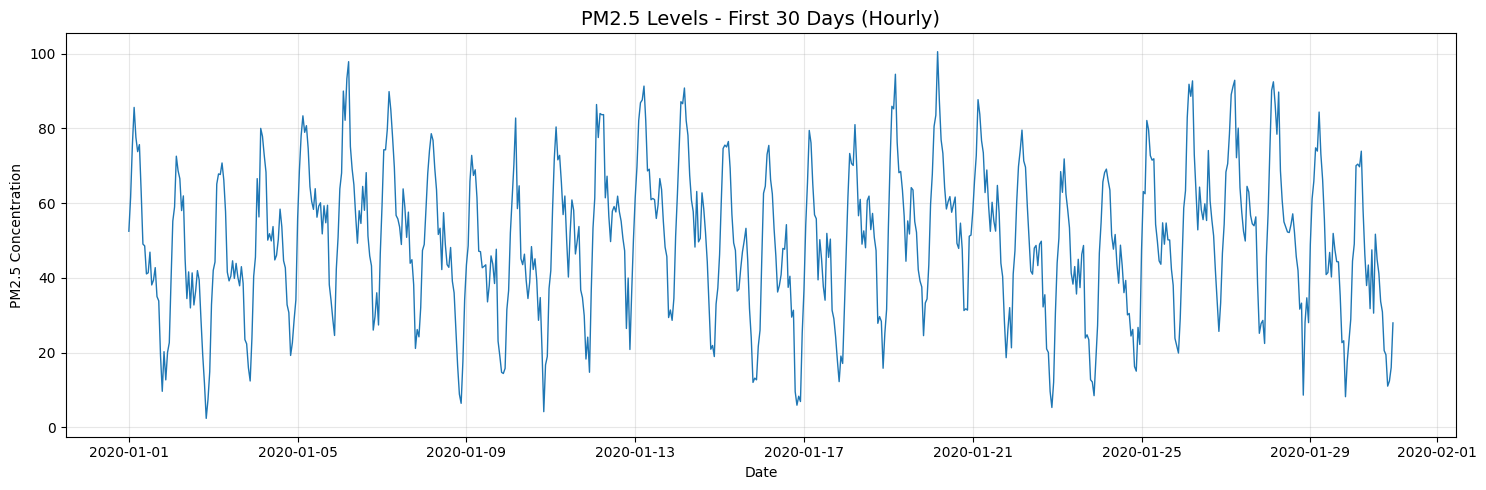

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(df['datetime'][:24*30], df['pm25'][:24*30], linewidth=1)
plt.title('PM2.5 Levels - First 30 Days (Hourly)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
- Clear **daily pattern**: values oscillate throughout the day
- Noisy signal: random fluctuations around the pattern
- This is typical of real-world time series data

## 2. Understanding Key Time Series Concepts

### Concept 1: Autoregression

**Autoregressive models** predict future values based on past values. The key idea: "Tomorrow's weather depends on today's weather."

Mathematically: $y_t = f(y_{t-1}, y_{t-2}, ..., y_{t-n})$

- $y_t$: value at time $t$
- $n$: **lookback window** (how many past timesteps to use)

**Example:** To predict PM2.5 at 3pm, we might use values from 12pm, 1pm, and 2pm (lookback=3).

### Concept 2: Forecast Horizon

The **forecast horizon** is how far into the future we predict.

- **Single-step**: Predict only the next timestep (e.g., next hour)
- **Multi-step**: Predict multiple future timesteps (e.g., next 24 hours)

We'll focus on **single-step forecasting** in this notebook, which is simpler but forms the foundation for multi-step approaches.

### Concept 3: Stationarity

A **stationary** time series has constant mean and variance over time. Non-stationary series (with trends/seasonality) are harder to model.

**Why it matters:** Many classical methods (ARIMA) assume stationarity. Neural networks are more flexible but still benefit from preprocessing.

**Common fixes:**
- **Differencing**: $y'_t = y_t - y_{t-1}$ (removes trends)
- **Normalization**: Scale to [0,1] or standardize to mean=0, std=1
- **Detrending**: Remove trend component

We'll use **normalization** — it's simple and works well with neural networks.

## 3. Data Preprocessing

### Step 1: Train/Validation/Test Split

**CRITICAL:** For time series, we can't use random splitting!

Why? Random splitting leaks future information into the training set, leading to overly optimistic results.

**Correct approach:** Split chronologically
- Train: First 70% of data
- Validation: Next 15%
- Test: Last 15%

This mimics real-world deployment: train on past data, predict the future.

In [6]:
# Extract values
data = df['pm25'].values

# Temporal split (70-15-15)
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

print(f"Train size: {len(train_data):,} hours ({len(train_data)/24:.1f} days)")
print(f"Val size: {len(val_data):,} hours ({len(val_data)/24:.1f} days)")
print(f"Test size: {len(test_data):,} hours ({len(test_data)/24:.1f} days)")

Train size: 12,264 hours (511.0 days)
Val size: 2,628 hours (109.5 days)
Test size: 2,628 hours (109.5 days)


### Step 2: Normalization

Neural networks train better when inputs are normalized. We'll use **MinMaxScaler** to scale values to [0, 1].

**Important:** Fit the scaler ONLY on training data to prevent data leakage.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
# Fit scaler on training data only
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()
val_data_scaled = scaler.transform(val_data.reshape(-1, 1)).flatten()
test_data_scaled = scaler.transform(test_data.reshape(-1, 1)).flatten()

print(f"Original range: [{train_data.min():.2f}, {train_data.max():.2f}]")
print(f"Scaled range: [{train_data_scaled.min():.2f}, {train_data_scaled.max():.2f}]")

Original range: [1.66, 110.31]
Scaled range: [0.00, 1.00]


### Step 3: Create Sliding Windows

To train autoregressive models, we need to create **input-output pairs** using a sliding window.

**Example** with lookback=3:
```
Data: [10, 20, 30, 40, 50, 60]

Window 1: Input=[10,20,30] → Target=40
Window 2: Input=[20,30,40] → Target=50
Window 3: Input=[30,40,50] → Target=60
```

Each window slides one timestep forward.

**Key hyperparameter:** `lookback` (how many past timesteps to use)
- Too small: Misses long-term patterns
- Too large: More parameters, harder to train, risk of overfitting

We'll start with `lookback=24` (24 hours of history to predict the next hour).

In [8]:
def create_sequences(data, lookback=24):
    """
    Create sliding window sequences for time series forecasting.
    
    Args:
        data: 1D array of values
        lookback: Number of timesteps to use as input
    
    Returns:
        X: Input sequences (n_samples, lookback)
        y: Target values (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# Hyperparameters
LOOKBACK = 24  # Use 24 hours to predict next hour

# Create sequences
X_train, y_train = create_sequences(train_data_scaled, LOOKBACK)
X_val, y_val = create_sequences(val_data_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_data_scaled, LOOKBACK)

print(f"X_train shape: {X_train.shape}  (samples, lookback)")
print(f"y_train shape: {y_train.shape}  (samples,)")
print(f"\nExample:")
print(f"Input (24 hours): {X_train[0][:5]}... → Target: {y_train[0]:.4f}")

X_train shape: (12240, 24)  (samples, lookback)
y_train shape: (12240,)  (samples,)

Example:
Input (24 hours): [0.46773992 0.55175958 0.67943207 0.77291844 0.69940644]... → Target: 0.3481


**Key insight:** We've transformed a sequential prediction problem into a supervised learning problem. Each window is a training example.

### Step 4: Create PyTorch Datasets and DataLoaders

We'll wrap our data in PyTorch's `Dataset` and `DataLoader` for efficient batching during training.

In [9]:
class TimeSeriesDataset(Dataset):
    """Simple dataset for time series sequences."""
    
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 192
Validation batches: 41
Test batches: 41


**Note:** We shuffle training data (breaks temporal order within epochs) but not validation/test. This is standard practice — it helps the model generalize better.

## 4. Model 1: MLP Baseline

### Why Start with an MLP?

A **Multi-Layer Perceptron** (simple feedforward network) serves as our baseline. It treats the sequence as a fixed-length feature vector, ignoring temporal structure.

**Architecture:**
- Input: Flattened sequence (24 values)
- Hidden layers with ReLU activation
- Output: Single prediction (next value)

**Limitation:** No explicit modeling of temporal dependencies. But it's fast and simple!

In [10]:
class MLPForecaster(nn.Module):
    """Simple MLP for time series forecasting."""
    
    def __init__(self, lookback, hidden_size=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(lookback, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size // 2, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, lookback)
        return self.network(x).squeeze(-1)  # Output: (batch_size,)

# Create model
mlp_model = MLPForecaster(lookback=LOOKBACK, hidden_size=128).to(device)

print(mlp_model)
print(f"\nParameters: {count_parameters(mlp_model):,}")

MLPForecaster(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parameters: 11,521


### Training Setup for MLP

We'll use:
- **MSE Loss** (Mean Squared Error): Standard for regression
- **Adam optimizer**: Adaptive learning rate, works well for most tasks
- **Learning rate scheduler**: Reduce LR when validation loss plateaus

In [11]:
# Training configuration
mlp_criterion = nn.MSELoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)
mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(mlp_optimizer, mode='min', factor=0.5, patience=5)

# Training history tracker
mlp_history = TrainingHistory()

### Training Loop for MLP

Standard training loop:
1. Forward pass
2. Compute loss
3. Backward pass
4. Update weights

In [12]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    """Evaluate model on validation/test set."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()
    
    return total_loss / len(loader)

### Train the MLP Model

We'll train for 50 epochs, monitoring validation loss to prevent overfitting.

In [13]:
NUM_EPOCHS = 50

print("Training MLP model...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(mlp_model, train_loader, mlp_criterion, mlp_optimizer, device)
    val_loss = evaluate(mlp_model, val_loader, mlp_criterion, device)
    
    mlp_history.update(train_loss=train_loss, val_loss=val_loss)
    mlp_scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print(f"\nBest validation loss: {mlp_history.get_best_value('val_loss', mode='min'):.6f}")

Training MLP model...


Epoch 10/50 - Train Loss: 0.005195, Val Loss: 0.003256


Epoch 20/50 - Train Loss: 0.003969, Val Loss: 0.003085


Epoch 30/50 - Train Loss: 0.003512, Val Loss: 0.003383


Epoch 40/50 - Train Loss: 0.003475, Val Loss: 0.003019


Epoch 50/50 - Train Loss: 0.003407, Val Loss: 0.002918

Best validation loss: 0.002906


### Visualize MLP Training Progress

Plotting training curves helps us understand:
- Whether the model is converging
- If there's overfitting (train loss << val loss)
- When to stop training

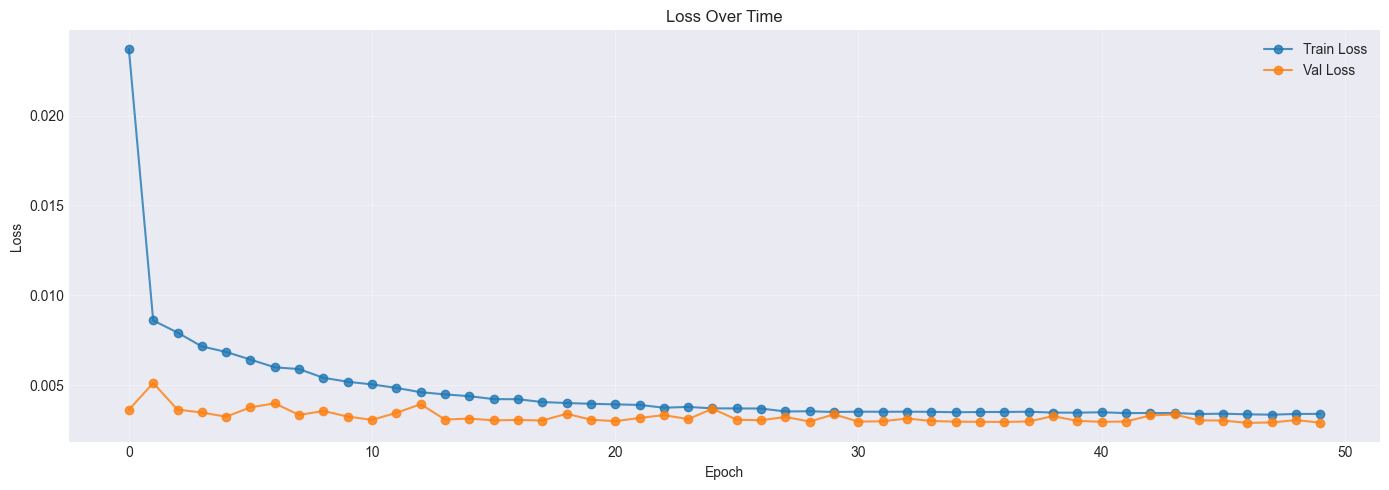

In [14]:
mlp_history.plot()

## 5. Model 2: LSTM (Long Short-Term Memory)

### Why LSTM?

The MLP treats the sequence as a bag of features. **LSTM** is designed for sequential data:

- **Memory cells**: Store information over long periods
- **Gates**: Control what information to keep/forget
- **Sequential processing**: Processes one timestep at a time

**Key components:**
- **Forget gate**: Decides what to discard from memory
- **Input gate**: Decides what new information to store
- **Output gate**: Decides what to output

LSTMs excel at capturing **temporal dependencies** — patterns that span multiple timesteps.

### LSTM Architecture

Our LSTM will have:
- Input: Sequence (batch_size, seq_length, input_size=1)
- LSTM layers: Process the sequence
- Fully connected: Map final hidden state to prediction

**Note:** We use the **final hidden state** to make the prediction (not all hidden states).

In [15]:
class LSTMForecaster(nn.Module):
    """LSTM for time series forecasting."""
    
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length)
        # LSTM expects: (batch_size, seq_length, input_size)
        x = x.unsqueeze(-1)  # Add feature dimension
        
        # LSTM output: (batch_size, seq_length, hidden_size)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use final hidden state for prediction
        # hidden shape: (num_layers, batch_size, hidden_size)
        final_hidden = hidden[-1]  # Take last layer: (batch_size, hidden_size)
        
        prediction = self.fc(final_hidden).squeeze(-1)  # (batch_size,)
        return prediction

# Create model
lstm_model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)

print(lstm_model)
print(f"\nParameters: {count_parameters(lstm_model):,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parameters: 50,497


**Observation:** LSTM has fewer parameters than MLP but is more powerful for sequential data.

### Training Setup for LSTM

Same configuration as MLP for fair comparison.

In [16]:
lstm_criterion = nn.MSELoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_scheduler = optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, mode='min', factor=0.5, patience=5)
lstm_history = TrainingHistory()

### Train the LSTM Model

Training loop is identical — the architecture handles sequential processing internally.

In [17]:
print("Training LSTM model...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(lstm_model, train_loader, lstm_criterion, lstm_optimizer, device)
    val_loss = evaluate(lstm_model, val_loader, lstm_criterion, device)
    
    lstm_history.update(train_loss=train_loss, val_loss=val_loss)
    lstm_scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print(f"\nBest validation loss: {lstm_history.get_best_value('val_loss', mode='min'):.6f}")

Training LSTM model...


Epoch 10/50 - Train Loss: 0.003507, Val Loss: 0.005369


Epoch 20/50 - Train Loss: 0.003198, Val Loss: 0.004021


Epoch 30/50 - Train Loss: 0.003054, Val Loss: 0.003681


Epoch 40/50 - Train Loss: 0.003011, Val Loss: 0.003926


Epoch 50/50 - Train Loss: 0.002909, Val Loss: 0.003529

Best validation loss: 0.003529


### Visualize LSTM Training Progress

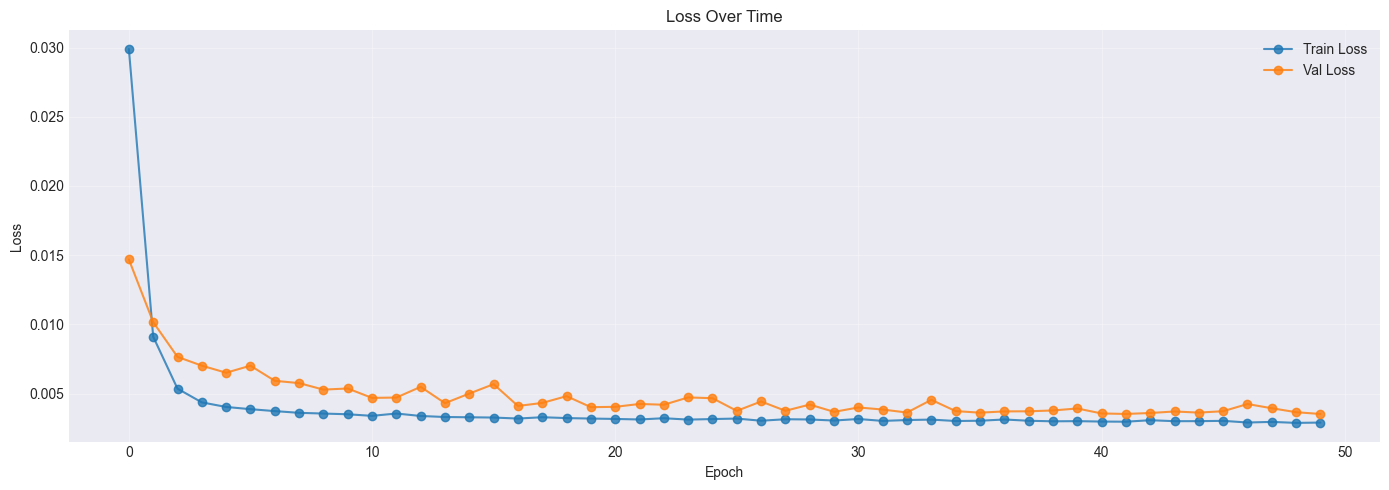

In [18]:
lstm_history.plot()

## 6. Model 3: Transformer

### Why Transformer?

LSTMs process sequences one step at a time (sequential). **Transformers** use **self-attention** to process all timesteps in parallel.

**Key advantages:**
- **Attention mechanism**: Weighs the importance of each timestep
- **Parallelizable**: Faster training than LSTM
- **Long-range dependencies**: Can attend to distant timesteps directly

**Self-attention intuition:**
When predicting the next value, the model asks: "Which past timesteps are most relevant?"

For example, to predict 3pm pollution:
- High attention to 2pm (most recent)
- Moderate attention to 9am (morning rush hour)
- Low attention to 3am (nighttime, less relevant)

### Transformer Architecture

We'll build a simplified Transformer:
- **Positional encoding**: Add position information (Transformers don't inherently know sequence order)
- **Transformer encoder**: Multi-head self-attention + feedforward layers
- **Pooling**: Aggregate sequence into single representation
- **Output layer**: Map to prediction

In [19]:
class PositionalEncoding(nn.Module):
    """Adds positional information to embeddings."""
    
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        # Create positional encodings
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerForecaster(nn.Module):
    """Transformer for time series forecasting."""
    
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        
        # Project input to d_model dimensions
        self.input_projection = nn.Linear(1, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output projection
        self.fc = nn.Linear(d_model, 1)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length)
        x = x.unsqueeze(-1)  # (batch_size, seq_length, 1)
        
        # Project to d_model dimensions
        x = self.input_projection(x)  # (batch_size, seq_length, d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoding
        x = self.transformer(x)  # (batch_size, seq_length, d_model)
        
        # Use last timestep for prediction (could also use mean pooling)
        x = x[:, -1, :]  # (batch_size, d_model)
        
        # Predict
        prediction = self.fc(x).squeeze(-1)  # (batch_size,)
        return prediction

# Create model
transformer_model = TransformerForecaster(
    d_model=64, 
    nhead=4, 
    num_layers=2, 
    dim_feedforward=128, 
    dropout=0.1
).to(device)

print(transformer_model)
print(f"\nParameters: {count_parameters(transformer_model):,}")

TransformerForecaster(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parameters: 67,137


### Training Setup for Transformer

In [20]:
transformer_criterion = nn.MSELoss()
transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=0.001)
transformer_scheduler = optim.lr_scheduler.ReduceLROnPlateau(transformer_optimizer, mode='min', factor=0.5, patience=5)
transformer_history = TrainingHistory()

### Train the Transformer Model

In [21]:
print("Training Transformer model...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(transformer_model, train_loader, transformer_criterion, transformer_optimizer, device)
    val_loss = evaluate(transformer_model, val_loader, transformer_criterion, device)
    
    transformer_history.update(train_loss=train_loss, val_loss=val_loss)
    transformer_scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print(f"\nBest validation loss: {transformer_history.get_best_value('val_loss', mode='min'):.6f}")

Training Transformer model...


Epoch 10/50 - Train Loss: 0.003589, Val Loss: 0.005128


Epoch 20/50 - Train Loss: 0.003196, Val Loss: 0.003329


Epoch 30/50 - Train Loss: 0.002935, Val Loss: 0.002926


Epoch 40/50 - Train Loss: 0.002845, Val Loss: 0.002825


Epoch 50/50 - Train Loss: 0.002776, Val Loss: 0.002776

Best validation loss: 0.002727


### Visualize Transformer Training Progress

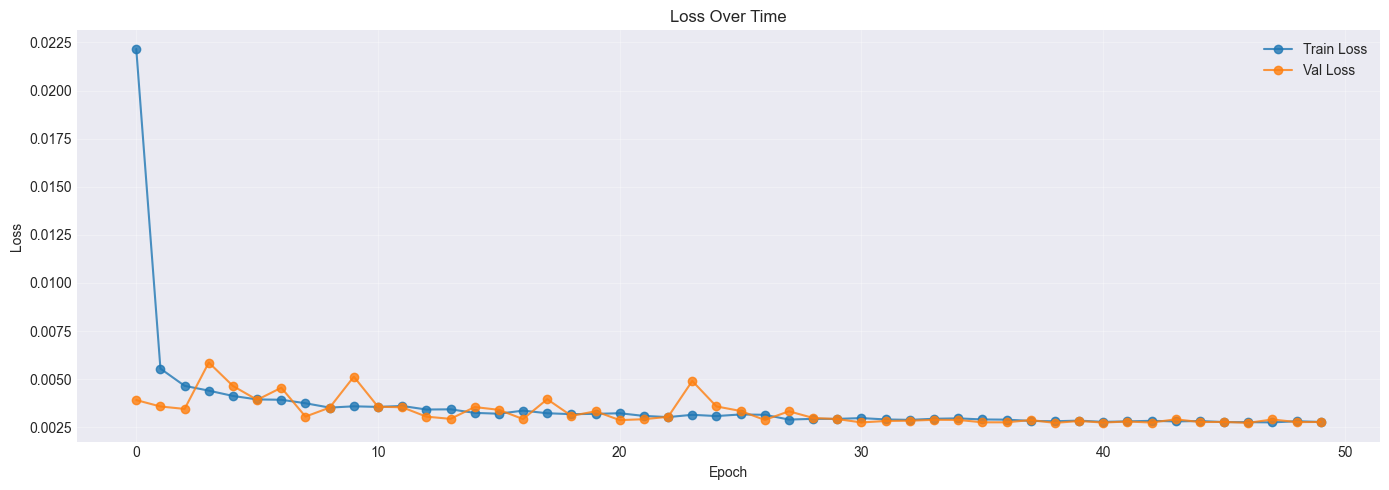

In [22]:
transformer_history.plot()

## 7. Model Evaluation and Comparison

### Forecasting Metrics

MSE loss is useful for training, but we need more interpretable metrics:

**1. MAE (Mean Absolute Error):**
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- Measures average prediction error in original units
- Easy to interpret: "On average, we're off by X PM2.5 units"

**2. RMSE (Root Mean Squared Error):**
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- Penalizes large errors more than MAE
- Also in original units

**3. MAPE (Mean Absolute Percentage Error):**
$$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|$$

- Scale-independent percentage error
- Useful for comparing across different scales

### Helper Function to Generate Predictions

We need to:
1. Get predictions from model (normalized scale)
2. Inverse transform to original scale
3. Compute metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
def get_predictions(model, loader, device, scaler):
    """
    Generate predictions and inverse transform to original scale.
    
    Returns:
        y_true: Actual values (original scale)
        y_pred: Predicted values (original scale)
    """
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            predictions.append(pred.cpu().numpy())
            actuals.append(y_batch.numpy())
    
    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    
    # Inverse transform to original scale
    predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    
    return actuals, predictions

def compute_metrics(y_true, y_pred):
    """Compute forecasting metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

### Evaluate All Models on Test Set

The test set is our final, unbiased estimate of real-world performance.

In [24]:
# Get predictions for all models
mlp_actuals, mlp_predictions = get_predictions(mlp_model, test_loader, device, scaler)
lstm_actuals, lstm_predictions = get_predictions(lstm_model, test_loader, device, scaler)
transformer_actuals, transformer_predictions = get_predictions(transformer_model, test_loader, device, scaler)

# Compute metrics
mlp_metrics = compute_metrics(mlp_actuals, mlp_predictions)
lstm_metrics = compute_metrics(lstm_actuals, lstm_predictions)
transformer_metrics = compute_metrics(transformer_actuals, transformer_predictions)

# Display results
results_df = pd.DataFrame({
    'MLP': mlp_metrics,
    'LSTM': lstm_metrics,
    'Transformer': transformer_metrics
})

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(results_df.round(3))
print("="*60)


TEST SET RESULTS
        MLP   LSTM  Transformer
MAE   4.696  5.110        4.499
RMSE  5.871  6.438        5.655
MAPE  7.962  8.463        7.715


**Interpretation:**

- **MAE/RMSE**: Lower is better. Shows average prediction error in PM2.5 units.
- **MAPE**: Lower is better. Shows percentage error.

Typically, LSTM and Transformer should outperform MLP for time series due to better temporal modeling.

### Visualize Predictions vs Actuals

Numbers are important, but **visualizations reveal patterns** metrics can't capture:
- Does the model capture trends?
- Does it lag behind actual values?
- Are there systematic biases?

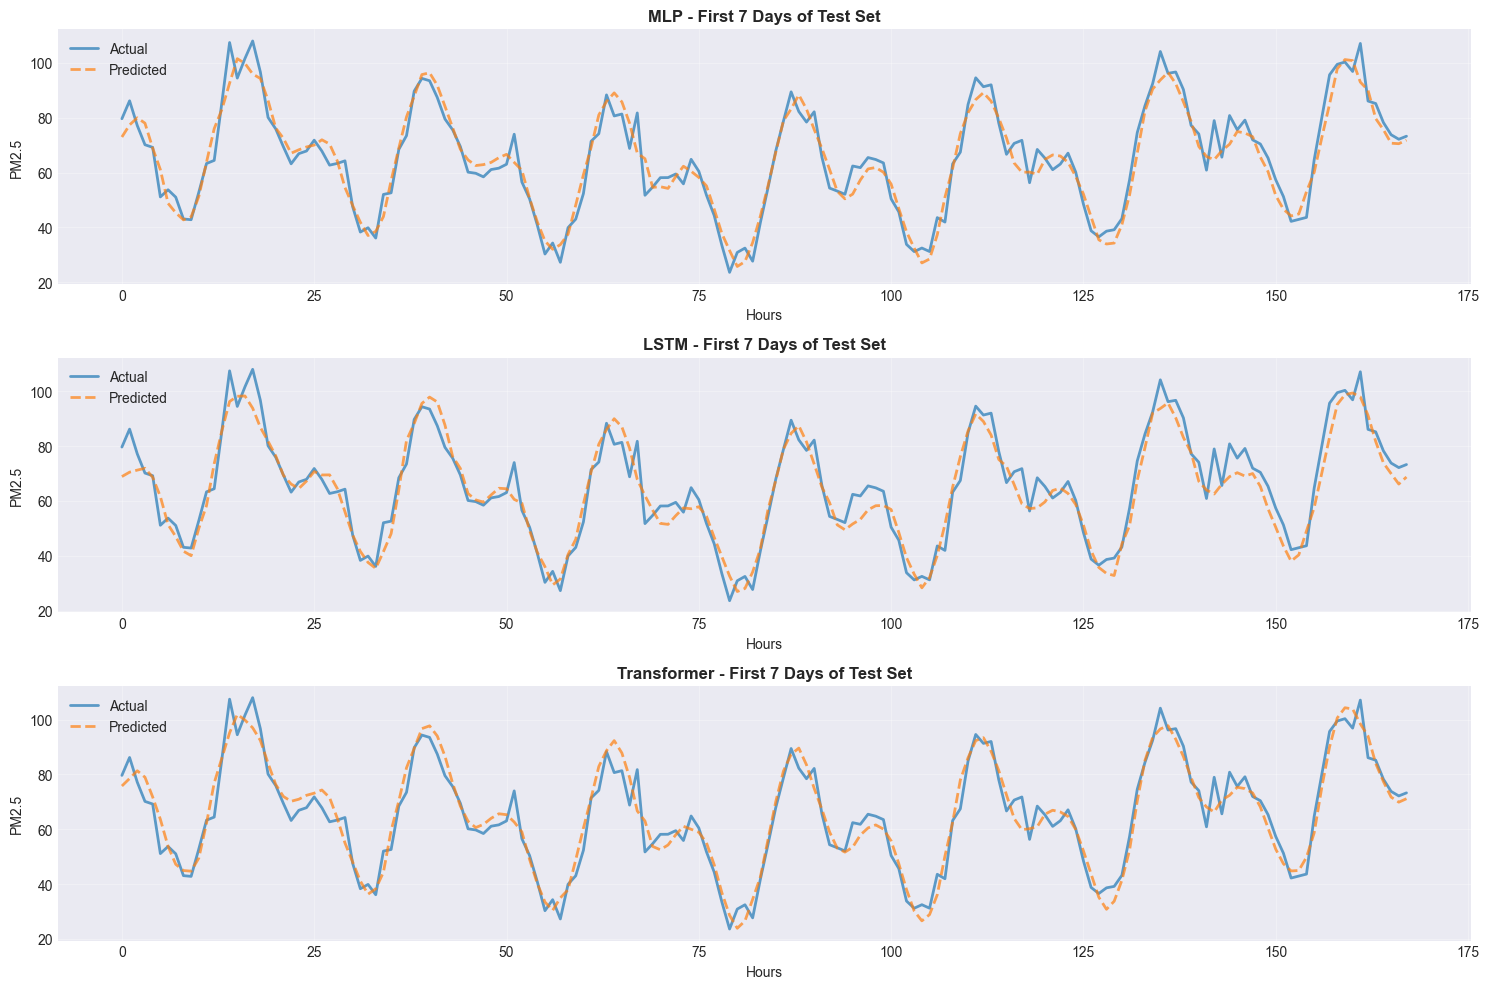

In [25]:
# Plot first 7 days of test predictions
n_hours_to_plot = 24 * 7

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
models = [
    ('MLP', mlp_actuals, mlp_predictions),
    ('LSTM', lstm_actuals, lstm_predictions),
    ('Transformer', transformer_actuals, transformer_predictions)
]

for ax, (name, actuals, predictions) in zip(axes, models):
    ax.plot(actuals[:n_hours_to_plot], label='Actual', linewidth=2, alpha=0.7)
    ax.plot(predictions[:n_hours_to_plot], label='Predicted', linewidth=2, alpha=0.7, linestyle='--')
    ax.set_title(f'{name} - First 7 Days of Test Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours')
    ax.set_ylabel('PM2.5')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations to look for:**

- **Phase alignment**: Do predictions follow the actual pattern?
- **Amplitude**: Are prediction magnitudes correct?
- **Lag**: Do predictions lag behind actuals? (Common issue)
- **Smoothness**: Over-smoothed predictions suggest model uncertainty

### Scatter Plot: Predicted vs Actual

Scatter plots reveal **systematic biases**:
- Perfect predictions lie on the diagonal
- Points above diagonal: over-prediction
- Points below diagonal: under-prediction

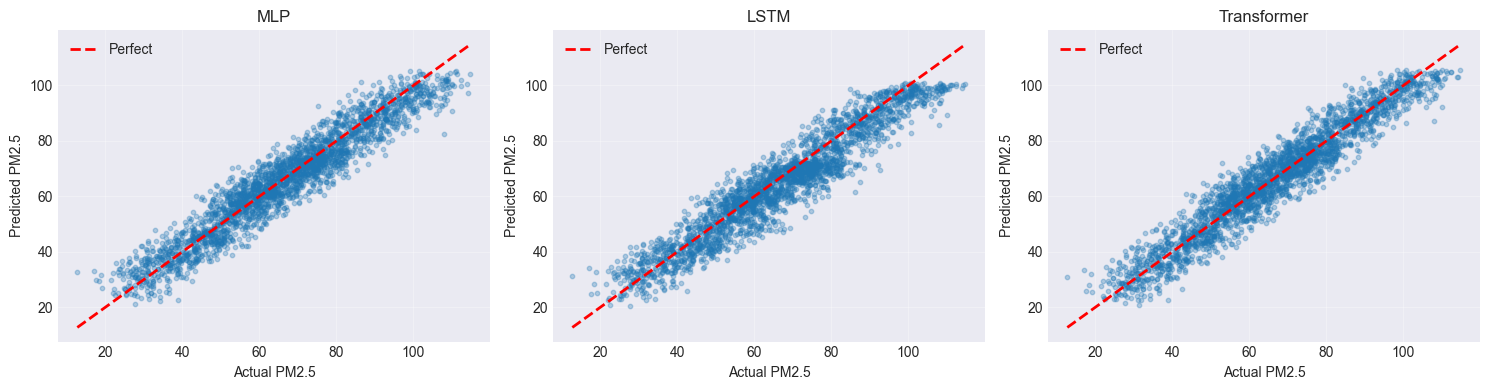

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, actuals, predictions) in zip(axes, models):
    ax.scatter(actuals, predictions, alpha=0.3, s=10)
    
    # Plot perfect prediction line
    min_val, max_val = actuals.min(), actuals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
    
    ax.set_xlabel('Actual PM2.5')
    ax.set_ylabel('Predicted PM2.5')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Understanding Model Behavior

### Error Analysis

Where do models make mistakes? Analyzing **residuals** (errors) reveals patterns:
- Are errors random (good) or systematic (bad)?
- Do errors correlate with actual values?
- Are there temporal patterns in errors?

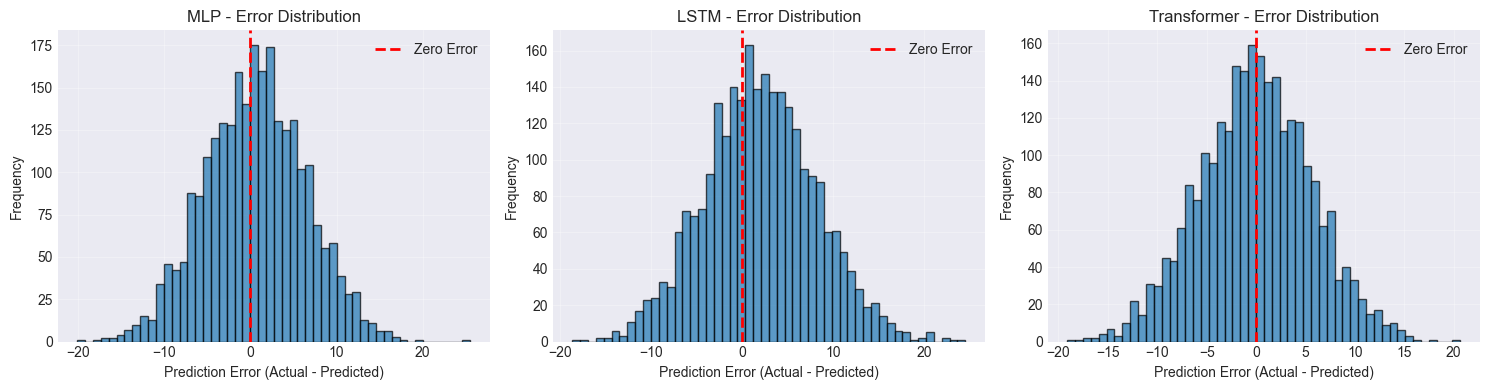

Residual Statistics:
MLP    - Mean: 0.544, Std: 5.846
LSTM   - Mean: 1.955, Std: 6.134
Transformer - Mean: -0.094, Std: 5.654


In [27]:
# Compute residuals
mlp_residuals = mlp_actuals - mlp_predictions
lstm_residuals = lstm_actuals - lstm_predictions
transformer_residuals = transformer_actuals - transformer_predictions

# Plot residual distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

residuals = [
    ('MLP', mlp_residuals),
    ('LSTM', lstm_residuals),
    ('Transformer', transformer_residuals)
]

for ax, (name, res) in zip(axes, residuals):
    ax.hist(res, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    ax.set_xlabel('Prediction Error (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} - Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Residual Statistics:")
print(f"MLP    - Mean: {mlp_residuals.mean():.3f}, Std: {mlp_residuals.std():.3f}")
print(f"LSTM   - Mean: {lstm_residuals.mean():.3f}, Std: {lstm_residuals.std():.3f}")
print(f"Transformer - Mean: {transformer_residuals.mean():.3f}, Std: {transformer_residuals.std():.3f}")

**Ideal residuals:**
- Centered at zero (no systematic bias)
- Bell-shaped (normally distributed)
- Small standard deviation (tight predictions)

If the mean is far from zero, the model systematically over/under-predicts.

## 9. Key Challenges in Time Series Forecasting

### Challenge 1: Distribution Shift

**Problem:** The future may not look like the past. 

Examples:
- Economic recessions (stock prices)
- Climate change (weather patterns)
- Black swan events (COVID-19)

**Solutions:**
- Regular model retraining
- Online learning (update model continuously)
- Domain adaptation techniques

### Challenge 2: Long-Term Dependencies

**Problem:** Important patterns may span long time periods.

Example: Predicting annual sales requires understanding yearly seasonality (365 days).

**Solutions:**
- Longer lookback windows (but more parameters)
- Hierarchical models (daily → weekly → monthly)
- Attention mechanisms (Transformers)

### Challenge 3: Multi-Horizon Forecasting

**Problem:** Uncertainty grows with prediction horizon.

Predicting tomorrow is easier than predicting next month.

**Solutions:**
- Train separate models per horizon
- Autoregressive decoding (feed predictions back as inputs)
- Direct multi-output models

### Challenge 4: Multivariate Forecasting

**Problem:** Real systems have multiple interacting variables.

Example: PM2.5 depends on temperature, humidity, wind, traffic, etc.

**Solutions:**
- Vector autoregression (VAR)
- Multi-input neural networks
- Graph neural networks (for spatial dependencies)

## 10. Experimentation: Impact of Lookback Window

### Does More History Help?

Let's test how the **lookback window** affects LSTM performance. Intuitively:
- Too small: Misses important patterns
- Too large: Overfitting, slower training

We'll compare lookback values: [6, 12, 24, 48, 72] hours.

In [28]:
lookback_values = [6, 12, 24, 48, 72]
lookback_results = []

print("Testing different lookback windows...\n")

for lookback in lookback_values:
    # Create sequences
    X_train_lb, y_train_lb = create_sequences(train_data_scaled, lookback)
    X_val_lb, y_val_lb = create_sequences(val_data_scaled, lookback)
    X_test_lb, y_test_lb = create_sequences(test_data_scaled, lookback)
    
    # Create datasets
    train_dataset_lb = TimeSeriesDataset(X_train_lb, y_train_lb)
    test_dataset_lb = TimeSeriesDataset(X_test_lb, y_test_lb)
    
    train_loader_lb = DataLoader(train_dataset_lb, batch_size=BATCH_SIZE, shuffle=True)
    test_loader_lb = DataLoader(test_dataset_lb, batch_size=BATCH_SIZE, shuffle=False)
    
    # Train small LSTM
    model_lb = LSTMForecaster(input_size=1, hidden_size=32, num_layers=1, dropout=0).to(device)
    optimizer_lb = optim.Adam(model_lb.parameters(), lr=0.001)
    criterion_lb = nn.MSELoss()
    
    # Quick training (20 epochs)
    for epoch in range(20):
        train_epoch(model_lb, train_loader_lb, criterion_lb, optimizer_lb, device)
    
    # Evaluate
    actuals_lb, predictions_lb = get_predictions(model_lb, test_loader_lb, device, scaler)
    metrics_lb = compute_metrics(actuals_lb, predictions_lb)
    
    lookback_results.append({
        'Lookback': lookback,
        'MAE': metrics_lb['MAE'],
        'RMSE': metrics_lb['RMSE'],
        'MAPE': metrics_lb['MAPE']
    })
    
    print(f"Lookback {lookback:2d}h - MAE: {metrics_lb['MAE']:.3f}, RMSE: {metrics_lb['RMSE']:.3f}, MAPE: {metrics_lb['MAPE']:.2f}%")

lookback_df = pd.DataFrame(lookback_results)
print("\n" + "="*60)
print(lookback_df.round(3))

Testing different lookback windows...



Lookback  6h - MAE: 6.984, RMSE: 8.737, MAPE: 11.26%


Lookback 12h - MAE: 6.215, RMSE: 8.201, MAPE: 9.99%


Lookback 24h - MAE: 4.780, RMSE: 5.973, MAPE: 8.17%


Lookback 48h - MAE: 4.585, RMSE: 5.753, MAPE: 7.74%


Lookback 72h - MAE: 4.817, RMSE: 6.003, MAPE: 8.00%

   Lookback    MAE   RMSE    MAPE
0         6  6.984  8.737  11.257
1        12  6.215  8.201   9.987
2        24  4.780  5.973   8.166
3        48  4.585  5.753   7.740
4        72  4.817  6.003   8.001


### Visualize Lookback Impact

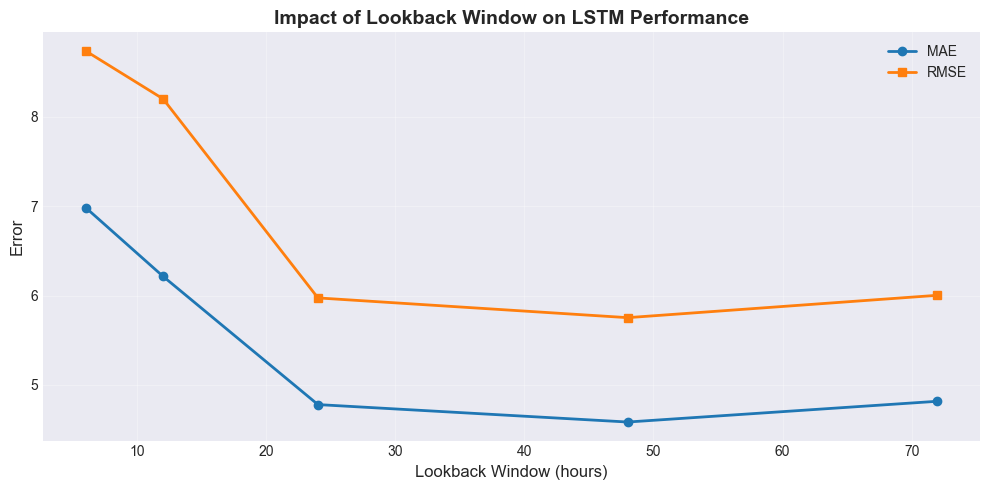

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lookback_df['Lookback'], lookback_df['MAE'], marker='o', linewidth=2, label='MAE')
ax.plot(lookback_df['Lookback'], lookback_df['RMSE'], marker='s', linewidth=2, label='RMSE')
ax.set_xlabel('Lookback Window (hours)', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Impact of Lookback Window on LSTM Performance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Typical pattern:**
- Error decreases initially (more context helps)
- Levels off or increases (diminishing returns, overfitting)
- Optimal lookback is dataset-specific

For daily patterns (like ours), 24h is often a good choice.

## 11. Key Takeaways

### What We Learned

**1. Time Series Fundamentals:**
- Temporal order matters — don't shuffle randomly!
- Use chronological train/val/test splits
- Sliding windows convert sequences into supervised learning

**2. Model Architectures:**
- **MLP**: Fast baseline, ignores temporal structure
- **LSTM**: Explicit memory cells for long-term dependencies
- **Transformer**: Attention-based, parallelizable, powerful

**3. Evaluation:**
- MSE for training, MAE/RMSE/MAPE for reporting
- Always visualize predictions vs actuals
- Analyze residuals for systematic biases

**4. Challenges:**
- Distribution shift (future ≠ past)
- Long-term dependencies (yearly patterns)
- Multi-horizon uncertainty
- Multivariate interactions

**5. Hyperparameter Impact:**
- Lookback window is critical
- More history helps until diminishing returns
- Domain knowledge guides choices (e.g., 24h for daily patterns)

### Connections to Broader Concepts

Time series forecasting builds on:
- **RNNs/LSTMs**: Sequential processing, memory
- **Attention/Transformers**: Weighting temporal relationships
- **Regression**: Predicting continuous values

It connects to:
- **Sequence-to-sequence**: Multi-step forecasting
- **Reinforcement learning**: Sequential decision making
- **Anomaly detection**: Finding unusual patterns in time

### Next Steps

To go deeper:

1. **Multivariate forecasting**: Use temperature, humidity, etc. as additional features
2. **Multi-step forecasting**: Predict next 24 hours simultaneously
3. **Probabilistic forecasting**: Predict distributions, not just point estimates
4. **Advanced architectures**: N-BEATS, DeepAR, Temporal Fusion Transformers
5. **Real datasets**: Stock prices, energy demand, weather data

### Final Thoughts

Time series forecasting is **everywhere** in the real world. The principles you've learned here — temporal ordering, lookback windows, appropriate metrics — apply broadly:

- Financial markets
- Supply chain optimization
- Energy grid management
- Healthcare monitoring
- Climate modeling

The challenge is not just building accurate models, but understanding **when they'll fail** (distribution shift) and **how to maintain them** (retraining, monitoring).

Always remember: **Past performance does not guarantee future results.** But with careful modeling and domain knowledge, we can make informed predictions.